In [1]:
import os
os.chdir('/mnt/c/rthomas/Pycode/echopop')
os.getcwd()
os.listdir()
from echopop import Survey
import echopop.extensions
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt

runyearstr=str(2023)
initpath="/mnt/c/rthomas/Projects/EchoPop_validation/EchoPop_config/initialization_config_"+ runyearstr+".yml"
configpath="/mnt/c/rthomas/Projects/EchoPop_validation/EchoPop_config/survey_year_"+runyearstr+"_config_test_wsl.yml"
survey = Survey( init_config_path = initpath , 
                survey_year_config_path = configpath )
# if wanted to read in NASC inputs from Echoview, would do here..
#pprint(survey.config["report_path"])
pprint(survey.meta)
pprint(survey.config)
report_base_dir=survey.config["report_path"]
datapass_path='/mnt/c/rthomas/Pycode/Learn_EchoPop/datapass'


{'provenance': {'date': '2025-02-11 15:25:44', 'imported_datasets': set()}}
{'CAN_haul_offset': 200,
 'NASC': {'all_ages': {'filename': 'Exports/2023/US_CAN_NASC_2023_table_all_ages.xlsx',
                       'sheetname': 'Sheet1'},
          'no_age1': {'filename': 'Exports/2023/US_CAN_NASC_2023_table_no_age1.xlsx',
                      'sheetname': 'Sheet1'}},
 'TS_length_regression_parameters': {'pacific_hake': {'TS_L_intercept': -68.0,
                                                      'TS_L_slope': 20.0,
                                                      'length_units': 'cm',
                                                      'number_code': 22500}},
 'biological': {'catch': {'CAN': {'filename': 'Biological/2023/CAN/2023061_DFO_biodata_catch.xlsx',
                                  'sheetname': 'DFO_biodata_catch'},
                          'US': {'filename': 'Biological/2023/US/202306_biodata_catch.xlsx',
                                 'sheetname': 'biodata_catch'}

In [2]:
#pprint(survey.input)
help(survey.load_survey_data)

Help on method load_survey_data in module echopop.survey:

load_survey_data(verbose: bool = True) method of echopop.survey.Survey instance
    Loads in biological and spatial survey data

    Parameters
    ----------

    verbose: bool
        Console messages that will print various messages, updates, etc. when ``verbose=True``



In [3]:

from echopop.utils.validate_df import AcousticData
import pandas as pd


#df = pd.read_excel("/mnt/c/rthomas/Projects/EchoPop_validation/data/Exports/EchoPro_Exports/US_CAN_NASC_2019_table_all_ages.xlsx")
#"C:\rthomas\Projects\EchoPop_validation\Data\Exports\EchoPro_Exports\US_CAN_NASC_2019_table_all_ages.xlsx"
#AcousticData.validate_df(df)
#df.columns

In [4]:

survey.load_acoustic_data(ingest_exports="echoview")
#survey.load_survey_data()
#pprint(survey.input)

Updated NASC export file for group 'all_ages' saved at '/mnt/c/rthomas/Projects/EchoPop_validation/data/Exports/EchoPro_Exports/US_CAN_NASC_2023_table_all_ages.xlsx'.
Updated NASC export file for group 'no_age1' saved at '/mnt/c/rthomas/Projects/EchoPop_validation/data/Exports/EchoPro_Exports/US_CAN_NASC_2023_table_no_age1.xlsx'.


In [5]:
survey.load_survey_data()

/mnt/c/rthomas/Pycode/echopop/echopop/utils/validate_df.py:69: UserWarning: The following row indices from /mnt/c/rthomas/Projects/EchoPop_validation/data/Biological/2023/CAN/2023061_DFO_biodata_catch.xlsx contained invalid values and were dropped from the validated DataFrame: [13, 14, 15, 23, 24, 25, 26, 27, 28, 41, 42, 43, 44, 61, 62, 63, 69, 76, 95, 104, 113, 114, 141, 142, 143, 144, 145, 146, 173, 174, 175, 176, 177, 178, 179, 189, 198, 210, 211, 212, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 239, 240, 241, 242, 243, 250, 251, 260, 261, 262, 263, 264, 265, 266, 267, 276, 285, 286, 289, 290, 291, 303, 315, 316, 317, 318, 319, 320, 321, 329, 330, 344, 345, 346, 347, 348, 349, 350]
  warnings.warn(


In [6]:
import sys
sys.executable

'/home/rthomas/miniforge3/envs/Py312/bin/python'

In [7]:
# Transect-level analysis  for ks
survey.transect_analysis(stratum='ks', exclude_age1=True)

--------------------------------
TRANSECT RESULTS
--------------------------------
| Variable: Biomass (kmt)
| Age-1 fish excluded: True
| Stratum definition: KS
--------------------------------
GENERAL RESULTS
--------------------------------
| Total biomass: 757.5 kmt
    Age-1: 21.3 kmt
    Age-2+: 736.3 kmt
| Total female biomass: 375.3 kmt
    Age-1: 9.6 kmt
    Age-2+: 365.6 kmt
| Total male biomass: 378.4 kmt
    Age-1: 11.6 kmt
    Age-2+: 366.8 kmt
| Total unsexed biomass: 3.8 kmt
| Total mixed biomass: 25.4 kmt
--------------------------------


In [8]:
#troubleshoot 2021 abundance issue 
temp=survey.transect_analysis(stratum='ks', exclude_age1=True)
#survey.analysis["transect"]  not what I want
temp=survey.analysis["transect"] ["acoustics"]["adult_transect_df"]["abundance"]
pprint(sum(temp))

--------------------------------
TRANSECT RESULTS
--------------------------------
| Variable: Biomass (kmt)
| Age-1 fish excluded: True
| Stratum definition: KS
--------------------------------
GENERAL RESULTS
--------------------------------
| Total biomass: 757.5 kmt
    Age-1: 21.3 kmt
    Age-2+: 736.3 kmt
| Total female biomass: 375.3 kmt
    Age-1: 9.6 kmt
    Age-2+: 365.6 kmt
| Total male biomass: 378.4 kmt
    Age-1: 11.6 kmt
    Age-2+: 366.8 kmt
| Total unsexed biomass: 3.8 kmt
| Total mixed biomass: 25.4 kmt
--------------------------------
2193998860.11791


In [9]:
## KS, with extrapolation
survey.kriging_analysis(extrapolate = True,best_fit_variogram=False, verbose=False)
# survey.kriging_analysis(cropping_parameters={"crop_method": "transect_ends",
#                                              "latitude_resolution": 1.25,
#                                              "bearing_tolerance": 15.0}, 
#                         kriging_parameters={"kmin": 3, "kmax": 10},
#                         best_fit_variogram=True,
#                         extrapolate=True,
#                         coordinate_transform=True,
#                         variable="biomass",
#                         verbose=True)
# export report
specific_report_path= os.path.join(report_base_dir,"KS/KwE")
#pprint(specific_report_path)
#survey.generate_reports(save_directory='/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2019/EchoPop/KS/KwE') ## KS, with extrapolation
survey.generate_reports(save_directory=specific_report_path)  #generate reports

The following report tables were generated:
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/aged_len_haul_counts_table.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/EchoPro_kriged_aged_output_0.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/EchoPro_kriged_aged_output_1.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/EchoPro_kriged_output_0.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/EchoPro_kriged_output_1.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/kriged_len_age_abundance_table.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/kriged_len_age_biomass_table.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/kriging_input.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KwE/total_len_haul_co

In [10]:
survey.summary("kriging")

--------------------------------
KRIGING RESULTS (MESH)
--------------------------------
| Kriged variable: Biomass (kg/nmi^2)
| Age-1 fish excluded: True
| Stratum definition: KS
| Mesh extrapolation: True
    Extrapolated over uncropped grid
| Mesh and transect coordinate standardization: True
--------------------------------
GENERAL RESULTS
--------------------------------
| Mean biomass: 6863.06 kg/nmi^2
| Total survey biomass estimate: 846.24 kmt
| Mean mesh sample CV: 0.0799
| Overall survey CV: 0.0868
| Total area coverage: 118187.6 nmi^2
--------------------------------


In [11]:
## KS, NO extrapolation
survey.kriging_analysis(extrapolate = False,best_fit_variogram=False, verbose=False)
specific_report_path= os.path.join(report_base_dir,"KS/KnE")
survey.generate_reports(save_directory=specific_report_path)  #generate reports

The following report tables were generated:
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/aged_len_haul_counts_table.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/EchoPro_kriged_aged_output_0.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/EchoPro_kriged_aged_output_1.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/EchoPro_kriged_output_0.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/EchoPro_kriged_output_1.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/kriged_len_age_abundance_table.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/kriged_len_age_biomass_table.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/kriging_input.xlsx'
   -'/mnt/c/rthomas/Projects/EchoPop_validation/Reports/2023/EchoPop/KS/KnE/total_len_haul_co

In [12]:
#Transect analysis for inpfc
survey.transect_analysis(stratum='inpfc', exclude_age1=True)
survey.stratified_analysis(dataset='transect',stratum='inpfc')

--------------------------------
TRANSECT RESULTS
--------------------------------
| Variable: Biomass (kmt)
| Age-1 fish excluded: True
| Stratum definition: INPFC
--------------------------------
GENERAL RESULTS
--------------------------------
| Total biomass: 712.8 kmt
    Age-1: 25.8 kmt
    Age-2+: 687.0 kmt
| Total female biomass: 354.0 kmt
    Age-1: 11.5 kmt
    Age-2+: 342.6 kmt
| Total male biomass: 354.8 kmt
    Age-1: 14.4 kmt
    Age-2+: 340.4 kmt
| Total unsexed biomass: 4.0 kmt
| Total mixed biomass: 25.2 kmt
--------------------------------
--------------------------------
 STRATIFIED RESULTS (TRANSECT)
--------------------------------
| Stratified variable: Biomass (kmt)
| Number of transects: 117
| Number of strata (INPFC): 6
| Total area coverage: 50780.0 nmi^2
| Age-1 fish excluded: True
| Bootstrap replicates: 10000 samples
| Resampling proportion: 0.75
| Bootstrap interval method: t-jackknife (CI: 95.0%)
--------------------------------
STRATUM-SPECIFIC ESTIMATES

In [13]:
## INPFC, with extrapolation

# this is where a new variogram analysis would go.
survey.kriging_analysis(extrapolate = True,best_fit_variogram=False)
# export report
specific_report_path= os.path.join(report_base_dir,"INPFC/KwE")
survey.generate_reports(save_directory=specific_report_path)  #generate reports

Longitude and latitude coordinates (WGS84) converted to standardized coordinates (x and y).
Extrapolation applied to kriging mesh points (8798 of 19843):
            * 8554 points had 0 valid range estimates without extrapolation
            * 244 points had at least 1 valid point but fewer than 3 valid neighbors
Imputed apportioned unaged male biomass at length bins:
(7.0, 9.0], (9.0, 11.0], (15.0, 17.0], (63.0, 65.0], (65.0, 67.0], (67.0, 69.0]
Imputed apportioned unaged female biomass at length bins:
(7.0, 9.0], (9.0, 11.0], (15.0, 17.0]
--------------------------------
KRIGING RESULTS (MESH)
--------------------------------
| Kriged variable: Biomass (kg/nmi^2)
| Age-1 fish excluded: True
| Stratum definition: INPFC
| Mesh extrapolation: True
    Extrapolated over uncropped grid
| Mesh and transect coordinate standardization: True
--------------------------------
GENERAL RESULTS
--------------------------------
| Mean biomass: 6480.63 kg/nmi^2
| Total survey biomass estimate: 799.2

In [14]:
## INPFC, with NO extrapolation
survey.transect_analysis(stratum='inpfc', exclude_age1=True)
# this is where a new variogram analysis would go.
survey.kriging_analysis(extrapolate = False,best_fit_variogram=False)
# export report
specific_report_path= os.path.join(report_base_dir,"INPFC/KnE")
survey.generate_reports(save_directory=specific_report_path)  #generate reports

--------------------------------
TRANSECT RESULTS
--------------------------------
| Variable: Biomass (kmt)
| Age-1 fish excluded: True
| Stratum definition: INPFC
--------------------------------
GENERAL RESULTS
--------------------------------
| Total biomass: 712.8 kmt
    Age-1: 25.8 kmt
    Age-2+: 687.0 kmt
| Total female biomass: 354.0 kmt
    Age-1: 11.5 kmt
    Age-2+: 342.6 kmt
| Total male biomass: 354.8 kmt
    Age-1: 14.4 kmt
    Age-2+: 340.4 kmt
| Total unsexed biomass: 4.0 kmt
| Total mixed biomass: 25.2 kmt
--------------------------------
Longitude and latitude coordinates (WGS84) converted to standardized coordinates (x and y).
Extrapolation applied to kriging mesh points (94 of 8666):
            * 90 points had 0 valid range estimates without extrapolation
            * 4 points had at least 1 valid point but fewer than 3 valid neighbors
Imputed apportioned unaged male biomass at length bins:
(7.0, 9.0], (9.0, 11.0], (15.0, 17.0], (63.0, 65.0], (65.0, 67.0], (67.0

In [15]:

survey.summary(results_name='stratified:transect')
survey.summary(results_name='transect') #unkriged
survey.summary(results_name='kriging')

--------------------------------
 STRATIFIED RESULTS (TRANSECT)
--------------------------------
| Stratified variable: Biomass (kmt)
| Number of transects: 117
| Number of strata (INPFC): 6
| Total area coverage: 50780.0 nmi^2
| Age-1 fish excluded: True
| Bootstrap replicates: 10000 samples
| Resampling proportion: 0.75
| Bootstrap interval method: t-jackknife (CI: 95.0%)
--------------------------------
STRATUM-SPECIFIC ESTIMATES
--------------------------------
| Stratum area coverage (n = 6):
    4264.0 | 7529.0 | 4560.0 | 6551.0 | 7670.0 | 20206.0 nmi^2
| Stratum mean biomass density (kmt/nmi^2):
    0.004 [-0.003, 0.009] | 0.028 [0.024, 0.032] | 0.063 [0.04, 0.08]
    0.021 [0.017, 0.026] | 0.004 [0.002, 0.005] | 0.001 [0.0, 0.001]
| Stratum mean biomass (kmt):
    17.5 [-12.1, 37.9] | 209.8 [178.5, 238.1] | 280.6 [173.6, 356.0]
    138.7 [112.1, 169.8] | 30.1 [13.1, 39.6] | 10.4 [4.4, 15.5]
--------------------------------
SURVEY RESULTS
--------------------------------
| Surve

In [16]:
pprint(survey.input["statistics"]["variogram"]["model_config"])

{'corr': 0.0,
 'correlation_range': 0.0055,
 'decay_power': 1.75,
 'hole_effect_range': 0.0,
 'lag_resolution': 0.002,
 'nugget': 0.0,
 'range': 0.006,
 'sill': 0.89,
 'ytox_ratio': 1.0,
 'ztox_ratio': 1.0}


In [17]:
#survey.variogram_gui()

In [18]:

#fig = survey.plot(kind="transect", variable="nasc")
#fig.savefig("insert_figure_filepath_name_here.png")


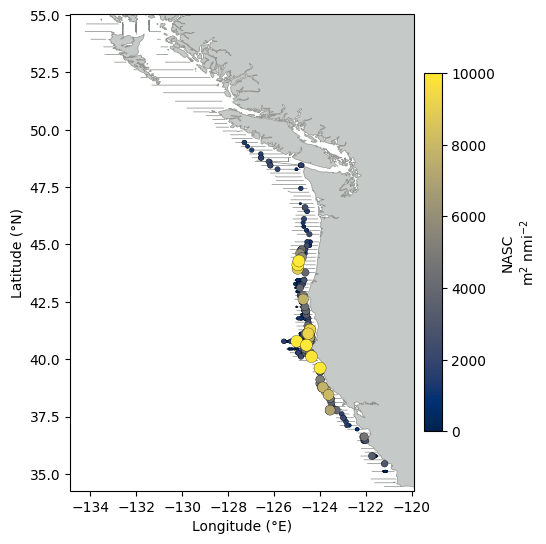

In [19]:
import matplotlib.pyplot as plt
c=survey.plot(kind="transect", variable="nasc")
#plt.savefig('output1.png', c)
#pprint(c)
#c.savefig("output1.png") #does not work yet

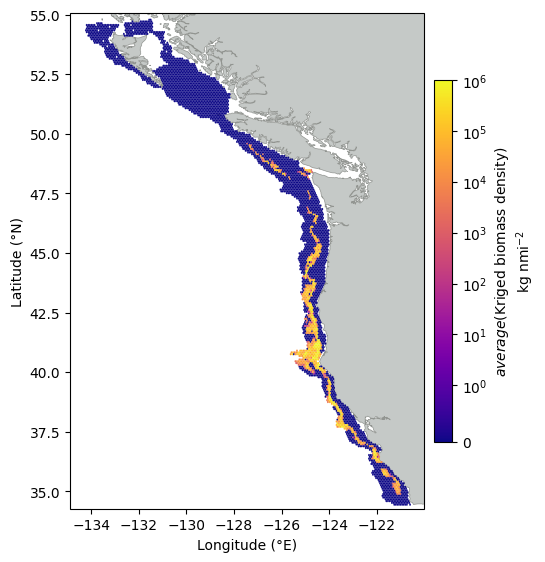

In [22]:

survey.plot(kind="mesh", 
            variable="biomass_density", 
            plot_type="hexbin", 
            plot_parameters={
                "reduce_C_function": np.sum, 
                "colorbar_label": "$average$(Kriged biomass density)\nkg nmi$^{-2}$",
                "log_base": 10})
#save

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
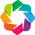

/mnt/c/rthomas/Pycode/echopop/echopop/extensions/diagnostics.py:369: UserWarning: Stratified kriging results are not available for plotting via the `Survey.stratified_results` diagnostic plotting method. Use the `Survey.kriging_analysis` method to compare stratified kriged estimates with those computed from just the along-transect dataset.
  warnings.warn(


KeyError: 'kriging'

In [23]:
survey.plot(kind="age_length_distribution", 
            variable="abundance", 
            plot_parameters={"log_base": 10})

In [21]:
#https://stackoverflow.com/questions/12309269/how-do-i-write-json-data-to-a-file

#import json
#stratified_data_fname= os.path.join(datapass_path,"summary_stratified_analysis.json")
#pprint(stratified_data_fname)
#temp=survey.summary(results_name='stratified:transect')
#temp=survey
#with open(stratified_data_fname, 'w', encoding='utf-8') as f:
#    json.dump(temp, f, ensure_ascii=False, indent=4)
#TypeError: Object of type Survey is not JSON serializable